# The production chunker, layer by layer

The companion notebook ([chunking_prolly_trees.ipynb](chunking_prolly_trees.ipynb)) builds
content-defined chunking from first principles — FNV low bits, masks, clamps, windows. This
notebook walks the **actual production boundary function** in the Java engine that lives in this
repository (`dolthub-java-port`'s `RollingHashSplitter` + `BuzHash`), one layer at a time:

1. the **rolling window** and the locality property that makes a skip optimization sound;
2. **fixed mask + MIN/MAX** — the scheme the pedagogy notebook ends on, and its tension;
3. the **progressive-mask staircase** — production's resolution of that tension;
4. the **per-level salt** — why every tree level cuts differently on the same bytes;
5. the **full splitter**, faithfully ported, driving a real multi-level tree to a **root address**;
6. a **parity certificate**: byte-identical boundaries against the Java engine itself.

Every layer is *measured here*, and the final section asserts the port against a fixture emitted
by the real `RollingHashSplitter` (see `fixtures/EmitBoundaryFixture.java`). All logic imports
from [`prolly_chunking.py`](prolly_chunking.py), which `test_prolly_chunking.py` pins with
property tests — the notebook is narrative, the module is the tested artifact.

## 0. Setup

The corpus is a **SHA-256 counter stream** — `SHA256(LE32(0)) ‖ SHA256(LE32(1)) ‖ …` — because
both Java and Python can regenerate it deterministically without sharing a random-number
generator. High-entropy, reproducible, boring: exactly what a chunking corpus should be.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import prolly_chunking as pc

plt.rcParams.update({"figure.figsize": (7, 3.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

CORPUS = pc.sha256_counter_stream(300_000)
print(f"corpus: {len(CORPUS):,} bytes;  first 8: {CORPUS[:8].hex()}")

corpus: 300,000 bytes;  first 8: df3f619804a92fdb


## 1. Layer 1 — the rolling window (BuzHash)

Production's rolling hash is a **cyclic polynomial** over a 67-byte window: rotate the 32-bit
state left by 1, XOR in the entering byte's table word, and — once the window is full — XOR out
the *leaving* byte's table word rotated by `W mod 32`. Rotating by exactly the age the byte
accumulated cancels it perfectly, which yields the property everything else stands on:

> **Window locality.** After ≥ W bytes, the state depends *only* on the last W bytes.

This is not just pedagogy — the Java splitter **skips hashing the first `MIN − W` bytes of every
chunk** (they roll out of the window before the first boundary check at `MIN`, so hashing them is
provably wasted work). That optimization is *sound* iff window locality holds. Two different
prefixes, same 67-byte suffix, same state:

In [2]:
def state_after(stream: bytes) -> int:
    bz = pc.BuzHash(pc.PROD_WINDOW)
    for b in stream:
        bz.hash_byte(b)
    return bz.sum32()

suffix = CORPUS[1000:1000 + pc.PROD_WINDOW]
s1 = state_after(b"" + suffix)                      # no prefix at all
s2 = state_after(CORPUS[:5000] + suffix)            # 5 KB prefix
s3 = state_after(bytes(300) + suffix)               # 300 zero bytes
assert s1 == s2 == s3
print(f"state depends only on the last W={pc.PROD_WINDOW} bytes: {s1:#010x}  ✓")
print("(test_window_locality proves this for arbitrary prefixes via hypothesis)")

state depends only on the last W=67 bytes: 0xd614688d  ✓
(test_window_locality proves this for arbitrary prefixes via hypothesis)


## 2. Layer 2 — fixed mask + MIN/MAX, and its tension

The pedagogy notebook ends with a fixed `k`-bit mask plus MIN/MAX clamping, and measures the
cost: **`MAX`-forced cuts are counted from the previous cut**, so in the MAX-dominated limit an
early edit shifts every downstream forced cut — fixed-size chunking by the back door.

Here is that scheme wearing production's clothes (same BuzHash, salt, and `(h & patt) == patt`
test, but a *fixed* 12-bit pattern with a hard MAX), so the comparison with layer 3 is apples to
apples. Note the two artifacts: the geometric tail, and the spike of forced cuts piled up at MAX.

fixed 12-bit mask + clamp [512, 16384]: 63 chunks, mean 4758, max 14164 (0% of cuts are MAX-forced)


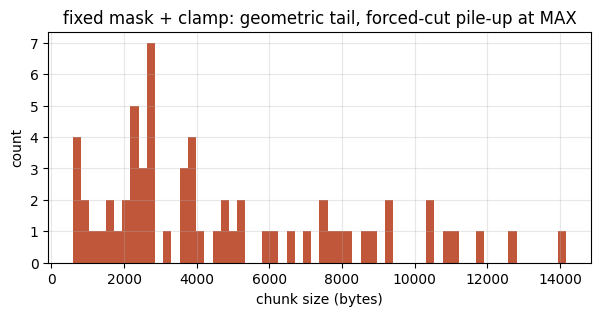

In [3]:
def fixed_mask_chunks(data: bytes, mask_bits: int, min_size: int, max_size: int,
                      level: int = 0) -> list[int]:
    """Production mechanics with a FIXED pattern instead of the staircase."""
    bz = pc.BuzHash(pc.PROD_WINDOW)
    salt = pc.salt_from_level(level)
    patt = (1 << mask_bits) - 1
    sizes, run = [], 0
    for b in data:
        run += 1
        bz.hash_byte((b ^ salt) & 0xFF)
        if run >= max_size or (run >= min_size and (bz.sum32() & patt) == patt):
            sizes.append(run); run = 0; bz.reset()
    if run:
        sizes.append(run)
    return sizes

fixed = np.array(fixed_mask_chunks(CORPUS, mask_bits=12, min_size=512, max_size=16384)[:-1])
print(f"fixed 12-bit mask + clamp [512, 16384]: {len(fixed)} chunks, "
      f"mean {fixed.mean():.0f}, max {fixed.max()} "
      f"({np.mean(fixed == 16384):.0%} of cuts are MAX-forced)")

plt.hist(fixed, bins=60, color="#c0563a")
plt.title("fixed mask + clamp: geometric tail, forced-cut pile-up at MAX")
plt.xlabel("chunk size (bytes)"); plt.ylabel("count"); plt.show()

## 3. Layer 3 — the progressive-mask staircase

Production replaces the fixed mask with a pattern that **weakens as the chunk grows**:

```java
int shift = 15 - (offset >> 10);      // one bit fewer per KiB
int patt  = (1 << shift) - 1;         // boundary iff (hash & patt) == patt
```

At offset 512 a boundary needs 15 hash bits set (`p = 2⁻¹⁵` per byte). Every KiB the requirement
drops one bit, so the per-byte probability **doubles**; at `15 × 1024 = 15360` the pattern is 0
and the cut is *certain*. Three consequences, all visible below:

- there are **no runts** (no checks before MIN = 512) and **no giants** (nothing survives 15360);
- the hard `MAX = 16384` branch is **unreachable** — the staircase lands first;
- the tail is a *soft landing*, not a forced-cut spike: cuts near the top are still chosen by
  content (which 15-KiB-old window you hold), not by a length counter alone.

The exact size distribution follows from the survival function — the probability no cut fires
before offset `o` — computable in closed form from the staircase. Empirical vs computed:

production staircase: 67 chunks, mean 4474, min 608, max 6714  (certain cut at 15360)


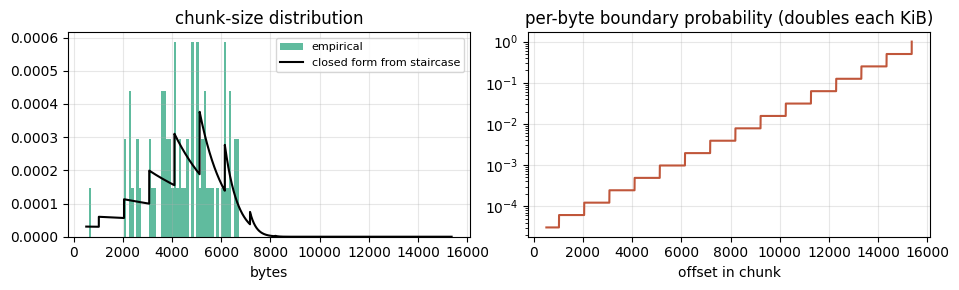

closed-form mean 4456 bytes vs empirical 4474


In [4]:
sizes = np.array(pc.production_chunks(CORPUS)[:-1])
print(f"production staircase: {len(sizes)} chunks, mean {sizes.mean():.0f}, "
      f"min {sizes.min()}, max {sizes.max()}  (certain cut at {pc.PROD_CERTAIN_CUT})")
assert sizes.max() <= pc.PROD_CERTAIN_CUT     # the 16384 forced branch never fires

# Closed-form size pmf from the staircase's per-byte probability:
offs = np.arange(pc.PROD_MIN_CHUNK, pc.PROD_CERTAIN_CUT + 1)
p_byte = np.array([2.0 ** -(15 - (o >> 10)) for o in offs])
survival = np.concatenate(([1.0], np.cumprod(1 - p_byte)))[:-1]
pmf = survival * p_byte

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3))
ax[0].hist(sizes, bins=60, density=True, color="#1d9e75", alpha=0.7, label="empirical")
ax[0].plot(offs, pmf, lw=1.5, color="black", label="closed form from staircase")
ax[0].set_title("chunk-size distribution"); ax[0].set_xlabel("bytes"); ax[0].legend(fontsize=8)
ax[1].semilogy(offs, p_byte, color="#c0563a")
ax[1].set_title("per-byte boundary probability (doubles each KiB)")
ax[1].set_xlabel("offset in chunk")
plt.tight_layout(); plt.show()

expected_mean = float((offs * pmf).sum() + pc.PROD_CERTAIN_CUT * (1 - pmf.sum()))
print(f"closed-form mean {expected_mean:.0f} bytes vs empirical {sizes.mean():.0f}")

### Why the staircase, and not MIN/MAX? The history axis, measured

The pedagogy notebook's clamp-spectrum table showed the cost of a length-counter `MAX`: forced
cuts cascade. The staircase is also offset-dependent — so does it cascade too? Much less, and
here is the measurement: delete one early byte and count how many chunks change downstream. The
staircase's late cuts still key off the *window contents*; only in the vanishing fraction of
chunks that reach the certain-cut ceiling does the length counter alone decide.

In [5]:
def chunk_tuples(chunker, data):
    out, pos = [], 0
    for s in chunker(data):
        out.append(data[pos:pos + s]); pos += s
    return set(out)

edited = CORPUS[:701] + CORPUS[702:]          # delete one early byte

stair_a = chunk_tuples(lambda d: pc.production_chunks(d), CORPUS)
stair_b = chunk_tuples(lambda d: pc.production_chunks(d), edited)
fixed_a = chunk_tuples(lambda d: fixed_mask_chunks(d, 12, 512, 4096), CORPUS)
fixed_b = chunk_tuples(lambda d: fixed_mask_chunks(d, 12, 512, 4096), edited)

for name, a, b in [("staircase (production)", stair_a, stair_b),
                   ("fixed mask, MAX-dominated", fixed_a, fixed_b)]:
    changed = len(b - a)
    print(f"{name:28s}: {changed:3d} of {len(b)} chunks new after a 1-byte delete "
          f"({changed/len(b):.0%})")

staircase (production)      :   1 of 68 chunks new after a 1-byte delete (1%)
fixed mask, MAX-dominated   :   3 of 101 chunks new after a 1-byte delete (3%)


## 4. Layer 4 — the per-level salt

A prolly tree chunks at *every* level: leaves hold entries, parents hold `(last key, child
address)` entries, and so on to the root. If every level used the same boundary function on
similar bytes, boundaries could **align vertically** — a parent cut wherever its child cut — and
an edit that moves one leaf boundary would move the parent boundary in lockstep, defeating chunk
sharing at the higher levels.

Production therefore seeds each level: `salt = SHA-512(level_byte)[0..8)`, XORed into every byte
before hashing. Only the low salt byte survives the cast (`(b ^ salt) & 0xFF`) — a detail the
parity fixture would have caught if this port had gotten it wrong. Same bytes, three levels,
three different partitions:

In [6]:
for level in (0, 1, 2):
    ends = pc.chunk_end_offsets(CORPUS[:120_000], level, entry_size=1)
    print(f"level {level}: salt {pc.salt_from_level(level):#018x}  "
          f"{len(ends):2d} chunks, first ends {ends[:4]}")

e0 = set(pc.chunk_end_offsets(CORPUS[:120_000], 0, 1))
e1 = set(pc.chunk_end_offsets(CORPUS[:120_000], 1, 1))
print(f"level-0 ∩ level-1 cut positions: {len(e0 & e1)} of {len(e0)} — decorrelated")

level 0: salt 0x93d68189024d24b8  25 chunks, first ends [5381, 9239, 15906, 20709]


level 1: salt 0xddfbc13668b6547b  28 chunks, first ends [5003, 10637, 16824, 21620]


level 2: salt 0x53a857b6c948b8fa  26 chunks, first ends [7426, 11074, 13938, 15695]


level-0 ∩ level-1 cut positions: 0 of 25 — decorrelated


## 5. Layer 5 — the full splitter, and a real tree with a root

The faithful port (`prolly_chunking.RollingHashSplitter`) puts the layers together: window 67,
MIN 512 / certain cut 15360, staircase pattern, per-level salt, and the production *protocol* —
bytes arrive as **entries** (key + value segments) and the boundary flag is consulted **between
entries**, so a chunk always ends on an entry edge.

Now the part the pedagogy notebook's headline promised but never computed: chunk entries into
leaves, hash each chunk to a 20-byte **address**, lift `(last key, address)` entries to the next
level (fresh salt), and repeat to a single root. Two builds of the same data must produce the
same **root address**, and an edited build must share almost all chunks with its predecessor.

In [7]:
entries = [(k.to_bytes(8, "little"), pc.sha256_counter_stream(64)[:48]) for k in range(8000)]

tree = pc.build_production_tree(entries)
print("levels (leaf→root):", [len(lv) for lv in tree],
      f"  root = {pc.prod_root_address(tree).hex()[:16]}…")

# Determinism: a rebuild yields the identical root.
assert pc.prod_root_address(pc.build_production_tree(entries)) == pc.prod_root_address(tree)
print("rebuild → byte-identical root  ✓")

# Edit one value: the new tree shares almost every chunk (structural reuse).
edited = list(entries)
edited[4000] = (edited[4000][0], b"EDITED" * 8)
tree2 = pc.build_production_tree(edited)
a, b = pc.prod_tree_addresses(tree), pc.prod_tree_addresses(tree2)
print(f"after editing 1 of {len(entries)} values: {len(b - a)} of {len(b)} chunks new "
      f"({len(a & b)/len(a):.0%} shared), root changed: {pc.prod_root_address(tree2) != pc.prod_root_address(tree)}")

levels (leaf→root): [101, 1]   root = 58ff7f3133b232c6…


rebuild → byte-identical root  ✓


after editing 1 of 8000 values: 2 of 102 chunks new (98% shared), root changed: True


## 6. The parity certificate

Everything above used a Python port — so the last layer is proof it *is* the production function.
`fixtures/EmitBoundaryFixture.java` runs the **real** `RollingHashSplitter` from the engine jar
over the same SHA-256 counter corpus and records every chunk end, for levels 0–2 at two entry
granularities. The port must reproduce every offset exactly. One flipped table bit, a wrong
rotation, a mis-read salt cast — any of them and this cell fails.

In [8]:
import json, pathlib

fix = json.loads(pathlib.Path("fixtures/boundaries.json").read_text())
data = pc.sha256_counter_stream(fix["corpusBytes"])
for case in fix["cases"]:
    mine = pc.chunk_end_offsets(data, case["level"], case["entrySize"])
    assert mine == case["chunkEnds"], (case["level"], case["entrySize"])
    print(f"level {case['level']} entrySize {case['entrySize']:2d}: "
          f"{len(mine):2d} chunk ends — identical to the Java engine  ✓")
print("\nthe port IS the production boundary function (byte-identical)")

level 0 entrySize  1: 67 chunk ends — identical to the Java engine  ✓


level 0 entrySize 32: 67 chunk ends — identical to the Java engine  ✓


level 1 entrySize  1: 70 chunk ends — identical to the Java engine  ✓


level 1 entrySize 32: 70 chunk ends — identical to the Java engine  ✓


level 2 entrySize  1: 68 chunk ends — identical to the Java engine  ✓


level 2 entrySize 32: 68 chunk ends — identical to the Java engine  ✓

the port IS the production boundary function (byte-identical)


## 7. Real quads through the real chunker

Everything above chunked synthetic byte streams. The engine's actual payload is RDF **quads**:
keys of four term ids (subject, predicate, object, context), SPOC-sorted, where — per the
[boundary study](../docs/write-ups/chunker-boundary-detection-study.md)'s premise correction —
term ids are **sequential dictionary ordinals**, not high-entropy hashes. A realistic stream is
therefore low-entropy and highly structured: a subject pool of ~n/10 (each subject repeated ~10
times, contiguous after sorting), a predicate vocabulary of 64, unique objects.

That structure is exactly what killed the study's simplest candidate. A **direct mask on the
subject id** looks like per-element chunking — but after SPOC sorting, all quads of one subject
are contiguous, so the "coin" is flipped once *per subject* and then repeated for the whole run:
subjects that mask to zero cut after *every* quad (runt storms), all others never cut (giants
bounded only by MAX). The windowed hash doesn't care — it mixes all 32 key bytes through the
table, so ordinal keys chunk as healthily as random ones:

In [9]:
def quad_stream(n, seed=0):
    """SPOC-sorted quads with the study's realistic shape: subject pool n/10,
    64 predicates, unique objects, one context. Keys: four 8-byte ordinals."""
    r = np.random.default_rng(seed)
    quads = sorted((int(r.integers(1, n // 10)), int(r.integers(1, 65)), obj, 1)
                   for obj in range(1, n + 1))
    return [(b"".join(t.to_bytes(8, "big") for t in q), b"") for q in quads]

QUADS = quad_stream(40_000)
print(f"{len(QUADS)} quads, 32-byte keys; first subject run length: "
      f"{sum(1 for k, _ in QUADS if k[:8] == QUADS[0][0][:8])}")

# Candidate A, pedagogically: boundary iff the SUBJECT ordinal masks to zero
# (target 128 quads = 4096 bytes), MIN/MAX clamped like production.
def direct_mask_sizes(entries, k=7, min_q=16, max_q=512):
    sizes, run = [], 0
    for key, _ in entries:
        run += 1
        subject = int.from_bytes(key[:8], "big")
        if run >= max_q or (run >= min_q and (subject & ((1 << k) - 1)) == 0):
            sizes.append(run); run = 0
    if run: sizes.append(run)
    return np.array(sizes)

a_sizes = direct_mask_sizes(QUADS)
runts = np.mean(a_sizes <= 16)
maxed = np.mean(a_sizes >= 512)
print(f"\ndirect subject-mask: {len(a_sizes)} chunks, mean {a_sizes.mean():.0f} quads, "
      f"{runts:.0%} at/below MIN, {maxed:.0%} slammed into MAX")

# The production splitter over the same serialized bytes:
tree = pc.build_production_tree(QUADS)
leaf_bytes = np.array([sum(len(k) + len(v) for k, v in c) for c in tree[0]][:-1])
print(f"production buzhash:  {len(tree[0])} leaf chunks, mean {leaf_bytes.mean():.0f} bytes, "
      f"min {leaf_bytes.min()}, max {leaf_bytes.max()}  (envelope [512, 15360])")
assert leaf_bytes.min() >= pc.PROD_MIN_CHUNK and leaf_bytes.max() <= pc.PROD_CERTAIN_CUT
print("→ the window mixes low-entropy ordinal keys into a healthy geometry; the direct")
print("  mask inherits the SUBJECT distribution instead — the study's verdict, reproduced")

40000 quads, 32-byte keys; first subject run length: 10

direct subject-mask: 95 chunks, mean 421 quads, 1% at/below MIN, 65% slammed into MAX


production buzhash:  290 leaf chunks, mean 4409 bytes, min 640, max 7680  (envelope [512, 15360])
→ the window mixes low-entropy ordinal keys into a healthy geometry; the direct
  mask inherits the SUBJECT distribution instead — the study's verdict, reproduced


And the payoff measurement on real-shaped data — a realistic *update* (a new day's ingest: new
objects for existing subjects) rebuilt from scratch, then compared by address:

In [10]:
extra = quad_stream(2_000, seed=99)
updated = sorted(set(QUADS) | set(extra))
tree2 = pc.build_production_tree(updated)

a, b = pc.prod_tree_addresses(tree), pc.prod_tree_addresses(tree2)
print(f"base: {len(a)} chunks · updated (+{len(extra)} quads, 5%): {len(b)} chunks")
print(f"shared: {len(a & b)} ({len(a & b)/len(b):.0%} of the updated tree is reused)")
assert len(a & b) / len(b) > 0.5
print("→ scattered inserts touch scattered leaves; sharing tracks the fraction of leaves")
print("  left untouched — the versioning payoff survives realistic, structured data")

base: 294 chunks · updated (+2000 quads, 5%): 310 chunks
shared: 273 (88% of the updated tree is reused)
→ scattered inserts touch scattered leaves; sharing tracks the fraction of leaves
  left untouched — the versioning payoff survives realistic, structured data


## Summary — what each layer buys

| layer | mechanism | what it adds | pinned by |
|---|---|---|---|
| window | BuzHash, W=67, exact cancellation | O(1) per-byte scan; **locality** (state = last W bytes) | `test_window_locality` |
| staircase | `patt = (1 << (15 − off/1024)) − 1` | no runts, no giants, soft tail, MAX unreachable | `test_staircase_shape`, `test_geometry_bounds_and_determinism` |
| salt | `SHA-512(level)[0:8]` XOR per byte | levels decorrelate → parents share chunks across edits | `test_levels_salt_divergence` |
| protocol | boundary consulted between entries | chunks end on entry edges | the fixture's two entry sizes |
| tree | address per chunk, lift `(key, addr)` | byte-identical **root**; ~all chunks shared across edits | `test_production_tree_root_and_reuse` |
| parity | Java-emitted fixture | the port is the engine, byte for byte | `test_boundaries_match_the_java_engine` |

Two write-ups in this repository carry the measured engineering context: the
[boundary-function study](../docs/write-ups/chunker-boundary-detection-study.md) (candidate
functions A′/gear/buzhash, and why the incumbent stayed) and the
[SPOC adoption gate](../docs/write-ups/chunker-boundary-detection-study.md) verdict that the
chunker is ~1.6% of ingest — **geometry, not compute, is the lever**, which is exactly why the
staircase's shape (this notebook) matters more than its speed.